# Aletheia - Main experiment findings

This notebook packages the completed Phikon-v2 colorectal audit into one judge-facing walkthrough. It uses the saved metrics and figure artifacts from the completed experiment: no placeholder KPIs and no simulated outputs.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path("/mnt/data/Aletheia-expanded")
FIG = ROOT / "assets" / "figures"

metrics = {
    "Patches analysed": 9999,
    "Tissue classes": 9,
    "Sparse features extracted": 4096,
    "Tissue-linked biological features": 410,
    "Artifact-sensitive features": 1674,
    "Matched ablation sets": 79,
}

summary = pd.DataFrame({
    "Metric": list(metrics.keys()),
    "Value": list(metrics.values()),
})
summary

,Metric,Value
0,Patches analysed,9999
1,Tissue classes,9
2,Sparse features extracted,4096
3,Tissue-linked biological features,410
4,Artifact-sensitive features,1674
5,Matched ablation sets,79


## Core readout

The strongest honest interpretation is that the representation contains two usable pathways at once: a morphology-dominant pathway that remains highly predictive on its own, and a stain-sensitive pathway that still carries substantial label information.

In [2]:
ablation = pd.DataFrame({
    "Condition": [
        "Combined baseline",
        "Remove clean biology",
        "Remove artifact-sensitive",
        "Biology only",
        "Artifact only",
    ],
    "Accuracy": [97.8, 48.1, 87.9, 97.0, 91.2],
})
ablation

,Condition,Accuracy
0,Combined baseline,97.8
1,Remove clean biology,48.1
2,Remove artifact-sensitive,87.9
3,Biology only,97.0
4,Artifact only,91.2


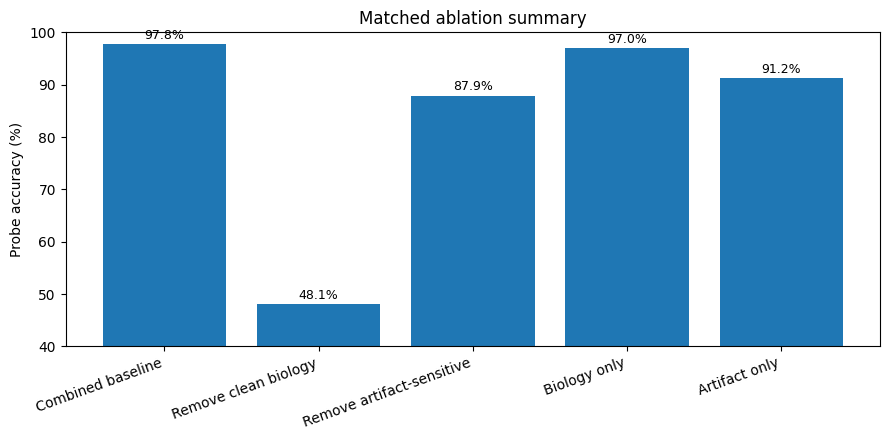

In [3]:
plt.figure(figsize=(9,4.5))
plt.bar(ablation["Condition"], ablation["Accuracy"])
plt.ylabel("Probe accuracy (%)")
plt.ylim(40, 100)
plt.xticks(rotation=20, ha="right")
plt.title("Matched ablation summary")
for i, v in enumerate(ablation["Accuracy"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## Figure artifacts

The completed experiment produced a clinical biology panel, an artifact-sensitive panel, the matched ablation summary, a representation-level activation patching follow-up, and a style-cluster stability follow-up.

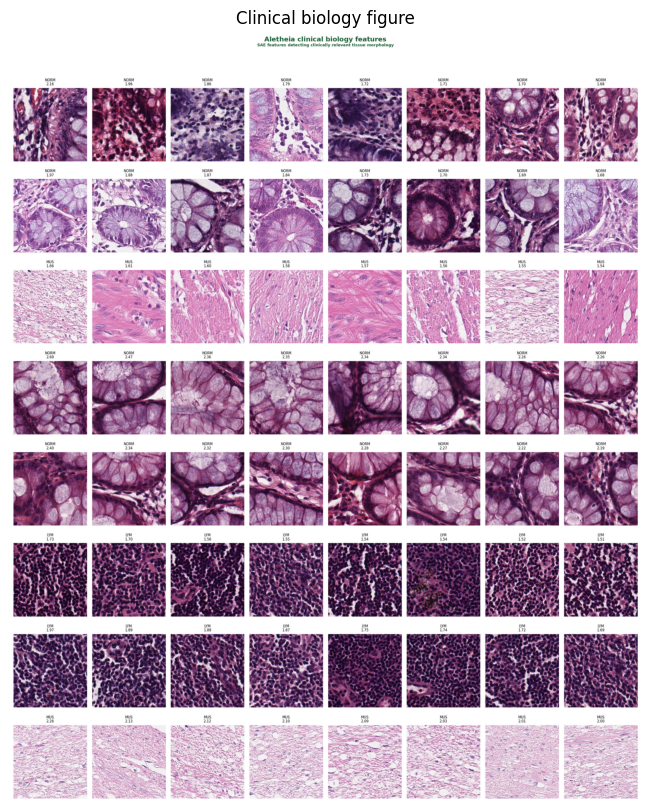

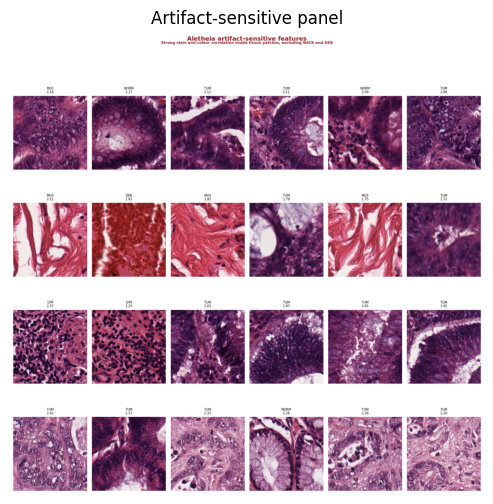

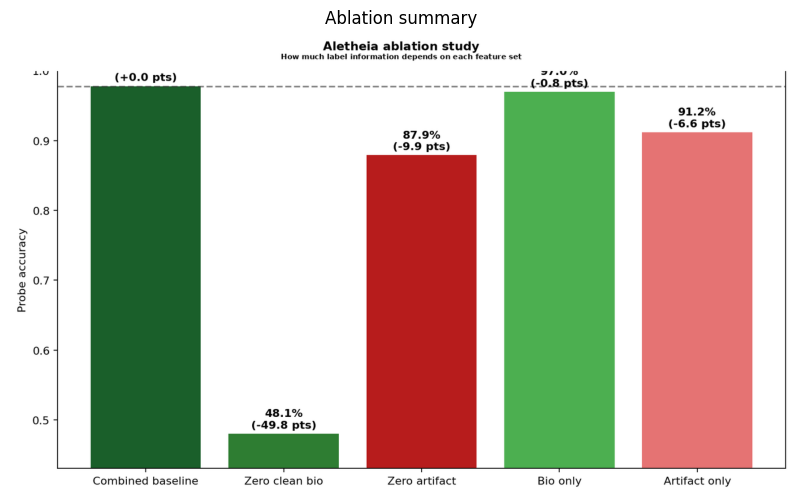

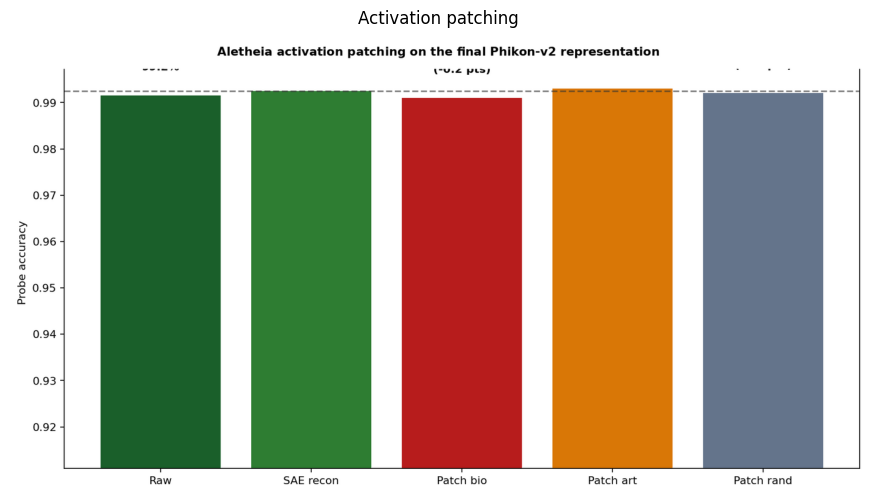

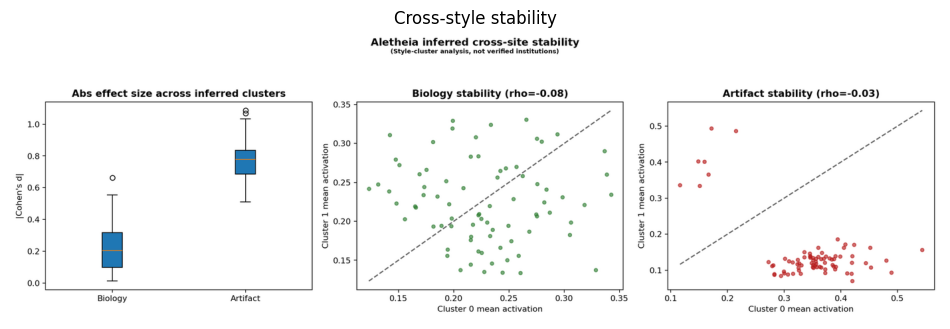

In [4]:
figure_order = [
    ("Clinical biology figure", "clinical_biology.png"),
    ("Artifact-sensitive panel", "artifact_sensitive.png"),
    ("Ablation summary", "ablation_summary.png"),
    ("Activation patching", "activation_patching.png"),
    ("Cross-style stability", "cross_site_stability.png"),
]
for title, filename in figure_order:
    img = Image.open(FIG / filename)
    plt.figure(figsize=(12, 6 if img.size[0] > img.size[1] else 10))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

## Representation-level follow-up

The follow-up patching result is a representation-level sensitivity test on the final normalized CLS representation before the embedding-level probe. It strengthens the case that the shortcut-sensitive features are part of the learned representation, but it is not yet a full-stack causal intervention on the end-to-end clinical system.

In [5]:
follow_up = pd.DataFrame({
    "Condition": [
        "SAE reconstruction baseline",
        "Patched biology set",
        "Patched artifact-sensitive set",
        "Patched random set",
    ],
    "Accuracy": [99.25, 99.10, 99.30, 99.20],
})
follow_up

,Condition,Accuracy
0,SAE reconstruction baseline,99.25
1,Patched biology set,99.10
2,Patched artifact-sensitive set,99.30
3,Patched random set,99.20


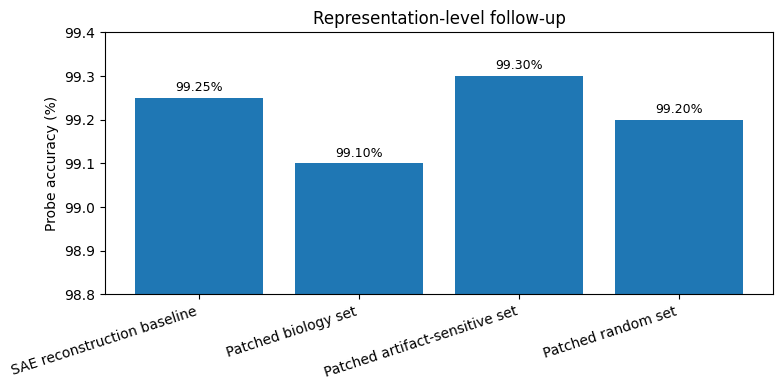

In [6]:
plt.figure(figsize=(8,4))
plt.bar(follow_up["Condition"], follow_up["Accuracy"])
plt.ylabel("Probe accuracy (%)")
plt.ylim(98.8, 99.4)
plt.xticks(rotation=18, ha="right")
plt.title("Representation-level follow-up")
for i, v in enumerate(follow_up["Accuracy"]):
    plt.text(i, v + 0.015, f"{v:.2f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## Stability readout

Across inferred style clusters, the clean biology family shifts less than the artifact-sensitive family. This is suggestive corroboration rather than a verified institution-level generalization claim.

In [7]:
stability = pd.DataFrame({
    "Family": ["Clean biology", "Artifact-sensitive"],
    "Median |Cohen\'s d|": [0.21, 0.78],
})
stability

,Family,Median |Cohen's d|
0,Clean biology,0.21
1,Artifact-sensitive,0.78


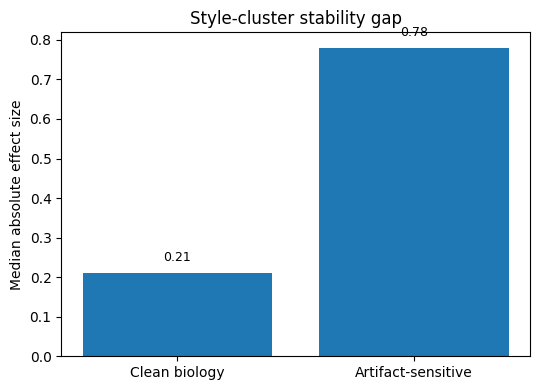

In [8]:
plt.figure(figsize=(5.5,4))
plt.bar(stability["Family"], stability["Median |Cohen\'s d|"])
plt.ylabel("Median absolute effect size")
plt.title("Style-cluster stability gap")
for i, v in enumerate(stability["Median |Cohen\'s d|"]):
    plt.text(i, v + 0.03, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## What this notebook is for

This notebook is designed to sit next to the evidence pack during a pitch, fellowship application, or technical conversation. It is not a claim of deployment safety or regulator-ready sufficiency. It is a compact, inspectable record of what the completed experiment did, what it found, and where the uncertainty still lives.